# Assignment 01: NeuroNav - Satellite Image Classification

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in the cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.
5. Have fun!


In [ ]:
# Enter your course email here as a string
course_email = "phitron@gmail.com"

# TEST CELL - Do not modify
assert isinstance(course_email, str)
assert "@" in course_email, "Please enter a valid email address!"
print(f"Email {course_email} registered successfully.")


Email phitron@gmail.com registered successfully.


## Story: NeuroNav's Earth Observation Project
You are a newly hired Machine Learning Engineer at **NeuroNav**, a startup that analyzes satellite imagery to monitor urbanization and deforestation. Your first project is to build a simple classification model that can distinguish between "Forest" and "Urban" areas based on two features:
- **Greenness Index (X1)**: A measure of vegetation.
- **Building Density (X2)**: A measure of man-made structures.

---
### Question 1: Theory (15 Marks)
**Part A (10 Marks):** Briefly explain the role of an activation function in a neural network, and why the Sigmoid activation function is often used in the output layer for binary classification problems (like our Forest vs. Urban problem).

**Part B (5 Marks):** Based on the limitations of a single-layer perceptron, why might a single perceptron struggle if the Forest and Urban areas are not linearly separable?


*Double click here to write your answer for Question 1*

**Part A Answer:**
Activations....


**Part B Answer:**
Limitation....




---
### Question 2: Data Preparation & Visualization (20 Marks)
Let's generate some synthetic data for NeuroNav. We will use `sklearn.datasets.make_blobs` to create a linearly separable dataset.

**Task:**
1. Generate 200 samples with 2 centers using `make_blobs`.
2. Create a scatter plot to visualize the 'Forest' (Class 1) and 'Urban' (Class 0) data points.


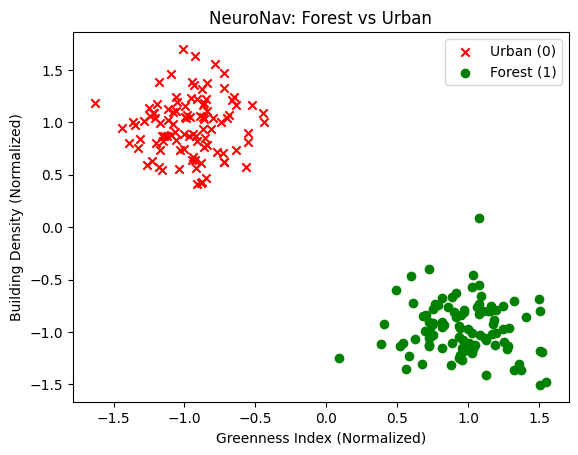

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate Data
# Create X and Y using make_blobs with 200 samples, 2 features, 2 centers, and random_state=42
# YOUR CODE HERE
X, Y = make_blobs(n_samples = 200 , n_features =2 , centers=2, random_state= 42)

# Normalize X for better training later
if 'X' in locals():
    X = (X - X.mean(axis=0)) / X.std(axis=0)

# 2. Visualize Data
plt.scatter(X[Y==0, 0], X[Y==0, 1], label='Urban (0)', c='red', marker='x')
plt.scatter(X[Y==1, 0], X[Y==1, 1], label='Forest (1)', c='green', marker='o')

plt.title("NeuroNav: Forest vs Urban")
plt.xlabel("Greenness Index (Normalized)")
plt.ylabel("Building Density (Normalized)")
plt.legend()
plt.show()

In [ ]:
# TEST CELL for Question 2
assert 'X' in locals() and 'Y' in locals(), "X and Y must be defined"
assert X.shape == (200, 2), "X should have shape (200, 2)"
assert Y.shape == (200,), "Y should have shape (200,)"
print("Question 2 Tests Passed!")

Question 2 Tests Passed!


---
### Question 3: Core Functions - Sigmoid and BCE Loss (20 Marks)
To train our model, we need an activation function to output probabilities and a loss function to measure our error.

**Task:**
1. Implement the `sigmoid(z)` function.
2. Implement the `binary_cross_entropy(y_true, y_pred)` function.


In [ ]:
def sigmoid(z):
    """
    Compute the sigmoid of z
    """
    # YOUR CODE HERE



def binary_cross_entropy(y_true, y_pred):
    """
    Compute the binary cross entropy loss.
    """
    # YOUR CODE HERE




In [ ]:
# TEST CELL for Question 3
test_z = np.array([0, 2, -2])
sig_out = sigmoid(test_z)
assert np.allclose(sig_out, [0.5, 0.880797, 0.119202], atol=1e-4), "Sigmoid function is incorrect"

test_y_true = np.array([1, 0, 1])
test_y_pred = np.array([0.9, 0.1, 0.8])
bce_out = binary_cross_entropy(test_y_true, test_y_pred)
assert np.isclose(bce_out, 0.1446, atol=1e-4), "BCE function is incorrect"

print("Question 3 Tests Passed!")


---
### Question 4: Single Perceptron Forward Pass (20 Marks)
Now, let's implement the forward pass for our single-layer perceptron.

**Task:**
Write a function `forward_pass(X, w, b)` that calculates the linear combination $Z = Xw + b$, and then applies the sigmoid activation to get the predictions $A$.


In [ ]:
def forward_pass(X, w, b):
    """
    Perform the forward pass.
    X: Input features, shape (m, n)
    w: Weights, shape (n, 1)
    b: Bias, scalar
    Returns:
    A: Output of the sigmoid activation (probabilities)
    """
    # YOUR CODE HERE




In [ ]:
# TEST CELL for Question 4
np.random.seed(1)
test_X = np.array([[1.5, 2.0], [3.0, 1.0]])
test_w = np.array([[0.5], [-0.5]])
test_b = 0.1

A_out = forward_pass(test_X, test_w, test_b)
assert A_out is not None, "forward_pass returned None"
assert A_out.shape == (2, 1), f"Expected shape (2, 1), got {A_out.shape}"
assert np.allclose(A_out, [[0.46257015], [0.75026011]], atol=1e-4), "Forward pass calculations are incorrect"

print("Question 4 Tests Passed!")


---
### Question 5: Training Loop & Decision Boundary (20 Marks)
It's time to train the perceptron using Gradient Descent!

**Task:**
1. Implement the gradient descent updates for `w` and `b` inside the training loop.
2. After training, run the provided code to visualize the decision boundary separating the Forest and Urban areas.


In [ ]:
def train_perceptron(X, Y, epochs, learning_rate):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0.0
    Y = Y.reshape(-1, 1)
    losses = []

    for epoch in range(epochs):
        # 1. Forward Pass
        A =

        # 2. Compute Loss
        loss =
        losses.append(loss)

        # 3. Compute Gradients (No need to Edit)
        dz = A - Y
        dw = (1 / m) * np.dot(X.T, dz)
        db = (1 / m) * np.sum(dz)

        # 4. Update Weights and Bias using Gradient Descent
        # YOUR CODE HERE
        w =
        b =

    return w, b, losses

# Train the model for 500 epochs with a 0.5 learning rate.
w_final, b_final, loss_history = train_perceptron()

# Plot the loss history
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy")
plt.show()


In [ ]:
# TEST CELL for Question 5
w_final, b_final, loss_history = train_perceptron(X, Y, epochs=500, learning_rate=0.5)
assert w_final.shape == (2, 1), "Weight shape is wrong"
assert loss_history[0] > loss_history[-1], "Loss should decrease over time"
print("Question 5 Training Loop logic appears correct!")



### Visualize the Decision Boundary
Run the cell below to see how well your model learned to separate Forest and Urban areas!


In [ ]:
# Run this cell to visualize the results
def plot_decision_boundary(X, Y, w, b):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = forward_pass(grid, w, b)
    Z = Z.reshape(xx.shape)
    Z = (Z > 0.5).astype(int)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlGn)
    plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k', cmap=plt.cm.RdYlGn)
    plt.title("NeuroNav: Perceptron Decision Boundary")
    plt.xlabel("Greenness Index")
    plt.ylabel("Building Density")
    plt.show()

# Uncomment below to plot
plot_decision_boundary(X, Y, w_final, b_final)


###**Example**

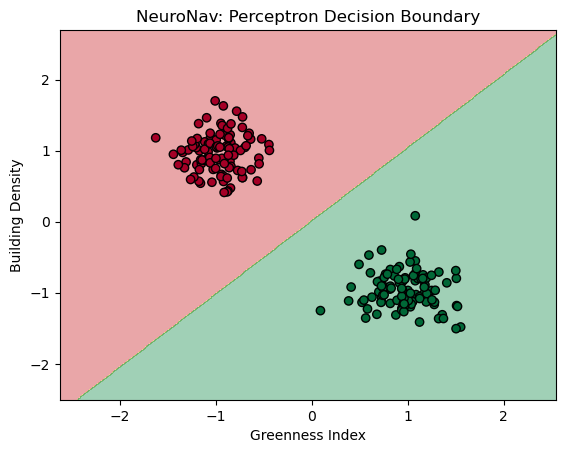

### Explain the Decision Boundary (5 Marks)

*Double click here to write your answer*

**Answer:**

---
### Congratulations!
You have successfully built a foundational machine learning model for NeuroNav. Ensure all your tests pass and submit this notebook.
